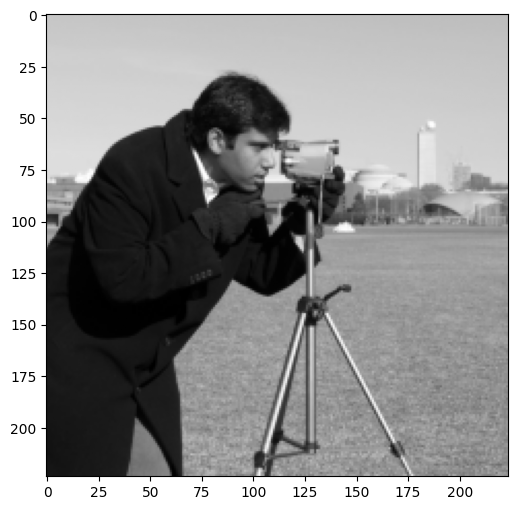

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data,color,transform

img_raw= data.camera()
img_raw= transform.resize(img_raw,(224,224))
plt.figure(figsize=(6,6))
plt.imshow(img_raw,cmap='gray')
plt.show()

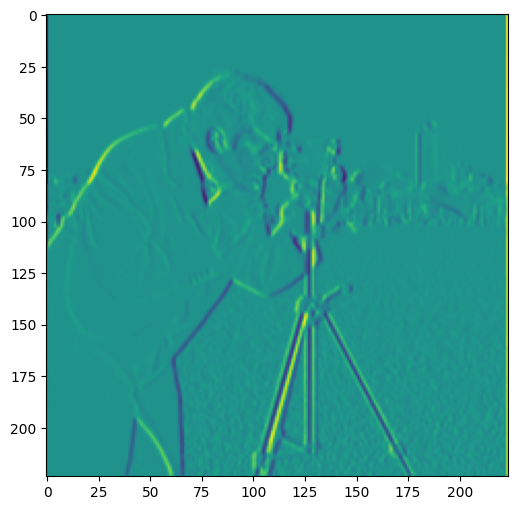

In [34]:
from scipy.signal import convolve2d
kernal = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
# img_gray = color.rgb2gray(img_raw)
feature_map = convolve2d(img_raw,kernal,mode='same')
plt.figure(figsize=(6,6))
plt.imshow(feature_map)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


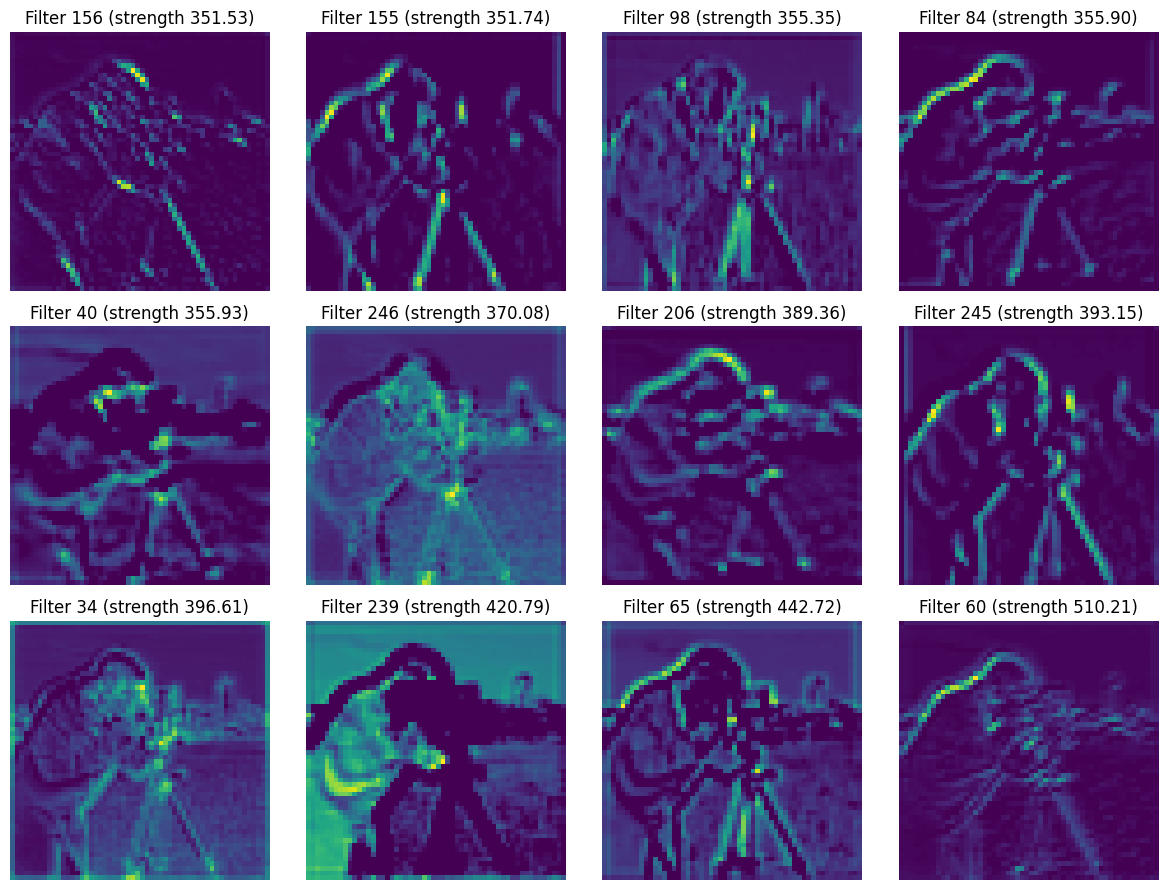

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import data, transform
import numpy as np
import matplotlib.pyplot as plt

#Load VGG16 (pre trained on imagenet)
model = VGG16(weights='imagenet', include_top=False)

# Prepare coins image
img_raw = data.camera()
img_rgb = color.gray2rgb(img_raw)  # convert grayscale to RGB
img_resized = transform.resize(img_rgb, (224, 224))

x = np.expand_dims(img_resized * 255, axis=0)  # VGG expects 0-255
x = preprocess_input(x)

def visualize_top_filters(layer_output, top_n=12):
    """
    Visualize the top N filters with strongest activations
    from a given layer output (shape: 1, H, W, N).
    """
    # Compute activation strength per filter (mean absolute value)
    strengths = np.mean(np.abs(layer_output[0]), axis=(0,1))

    # Sort filters by strength
    top_indices = np.argsort(strengths)[-top_n:]

    # Plot them in a grid
    cols = 4
    rows = int(np.ceil(top_n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))

    for i, idx in enumerate(top_indices):
        ax = axes.flat[i]
        ax.imshow(layer_output[0,:,:,idx], cmap='viridis')
        ax.set_title(f"Filter {idx} (strength {strengths[idx]:.2f})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
mid_layer_model = tf.keras.models.Model(inputs=model.input, outputs=model.get_layer('block3_conv1').output)
mid_layer_output = mid_layer_model.predict(x)
visualize_top_filters(mid_layer_output, top_n=12)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step


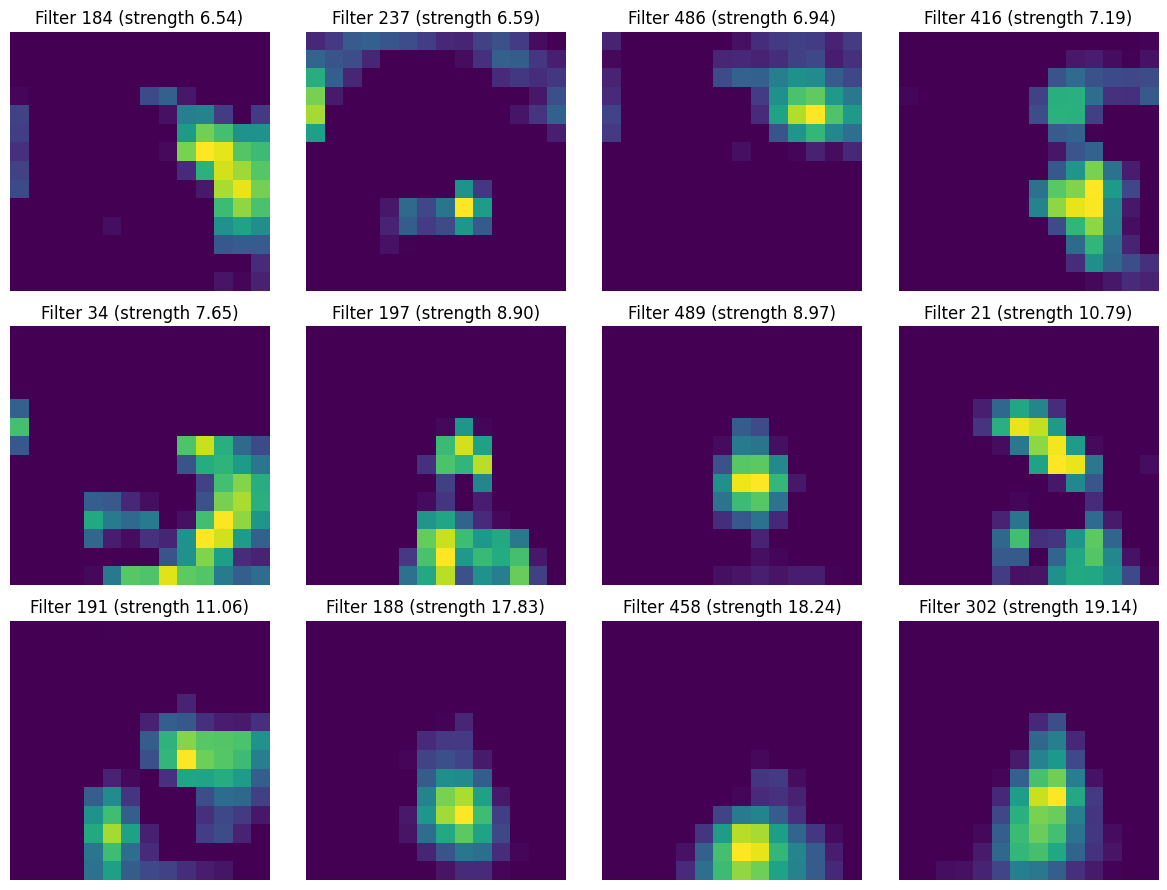

In [37]:
# Extract the final convolution layer (Block 5, Conv 3)
deep_layer_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('block5_conv3').output
)
deep_features = deep_layer_model.predict(x)
#visualise top 12 features based on strengths
visualize_top_filters(deep_features, top_n=12)
